# Week 1 — Data Acquisition, Cleaning & EDA
### Dataset: Titanic — Machine Learning from Disaster (Kaggle)

**Goal:** Acquire the Titanic dataset, clean it, and perform exploratory data analysis (EDA) to understand the factors related to passenger survival.

This notebook is designed to run top-to-bottom in **Google Colab**.


## 1. Setup & Data Acquisition

In [12]:
# 1.1 Install/import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


In [13]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

train_file = [f for f in uploaded if 'train' in f.lower()][0]
train = pd.read_csv(train_file)

test_files = [f for f in uploaded if 'test' in f.lower()]

if test_files:
    test = pd.read_csv(test_files[0])
else:
    test = None

print("Train:", train.shape)
print("Test:", test.shape if test is not None else "Not provided")

Saving train.csv to train (1).csv
Saving test.csv to test (1).csv
Train: (891, 12)
Test: (418, 11)


> **Note:** If you'd rather not use the upload widget, you can instead mount Google Drive
> (`from google.colab import drive; drive.mount('/content/drive')`) and read the CSV from there,
> or download directly from Kaggle using the Kaggle API if you have a `kaggle.json` token.

## 2. Initial Inspection

In [14]:
# 2.1 Basic structure
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
# 2.2 Statistical summary
train.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [16]:
# 2.3 Check for duplicate rows
n_dupes = train.duplicated().sum()
print(f"Number of fully duplicated rows: {n_dupes}")

# Also check for duplicate PassengerId (should be unique identifiers)
print(f"Duplicate PassengerId values: {train['PassengerId'].duplicated().sum()}")


Number of fully duplicated rows: 0
Duplicate PassengerId values: 0


**Why check duplicates this way?**
A fully duplicated row (every column identical) is almost always a data-entry error and should be dropped.
But because `PassengerId` is a unique key, checking it separately confirms whether the dataset has any
accidental duplicate records that a full-row check might miss (e.g. if one field differs slightly).

In [17]:
# 2.4 Drop duplicates if any were found (safe no-op if none exist)
before = train.shape[0]
train = train.drop_duplicates()
after = train.shape[0]
print(f"Dropped {before - after} duplicate rows.")


Dropped 0 duplicate rows.


## 3. Missing Values

In [18]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_summary


,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


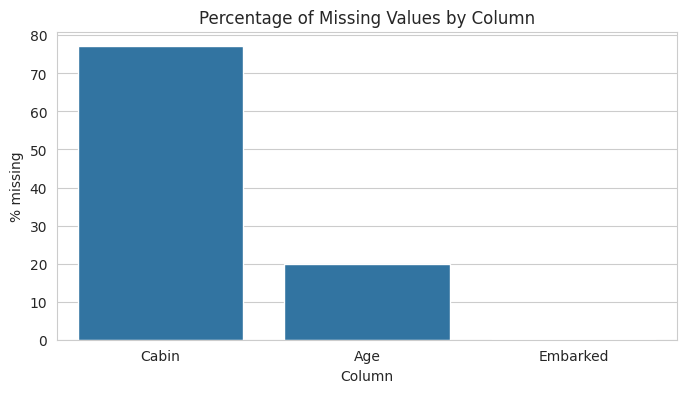

In [19]:
# Visualize missingness
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_pct'])
plt.title("Percentage of Missing Values by Column")
plt.ylabel("% missing")
plt.xlabel("Column")
plt.show()


**Cleaning decisions & rationale:**

- **`Cabin` (~77% missing):** Too sparse to impute reliably. Instead of dropping the column outright
  (it may still hold signal), we engineer a binary feature `Has_Cabin` (1 if cabin info exists, 0 otherwise) —
  cabin data being recorded at all correlates with ticket class/fare, so it's informative even when the
  actual cabin number is missing.
- **`Age` (~20% missing):** Numeric and roughly continuous. Rather than a single global median (which would
  distort the distribution across passenger classes), we impute using the **median Age within each
  `Pclass` + `Sex` group**, since age tends to vary systematically with those factors (e.g. 1st class
  passengers skewed older).
- **`Embarked` (2 missing):** Categorical with very few missing values — safe to impute with the **mode**
  (most frequent port), since it won't meaningfully bias such a small number of rows.
- **`Fare` (test set only, 1 missing):** Impute with the median fare for that passenger's `Pclass`.


In [20]:
# 3.1 Has_Cabin flag
train['Has_Cabin'] = train['Cabin'].notnull().astype(int)

# 3.2 Impute Age using median per Pclass + Sex group
train['Age'] = train.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# 3.3 Impute Embarked with mode
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# Re-check missing values (Cabin is expected to remain, we've captured its signal in Has_Cabin)
train.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [21]:
# Apply the same cleaning logic to the test set, if provided
if test is not None:
    test['Has_Cabin'] = test['Cabin'].notnull().astype(int)
    test['Age'] = test.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
    test['Fare'] = test.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
    if test['Embarked'].isnull().sum() > 0:
        test['Embarked'] = test['Embarked'].fillna(train['Embarked'].mode()[0])
    print(test.isnull().sum())


PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
Has_Cabin        0
dtype: int64


## 4. Data Type Corrections

In [22]:
# Convert categorical-looking numeric columns into proper 'category' dtype
cat_cols = ['Survived', 'Pclass', 'Sex', 'Embarked']
for c in cat_cols:
    if c in train.columns:
        train[c] = train[c].astype('category')

train.dtypes


,0
PassengerId,int64
Survived,category
Pclass,category
Name,object
Sex,category
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


**Why convert these to `category`?** `Survived`, `Pclass`, `Sex`, and `Embarked` are coded as numbers or
strings but represent discrete groups, not continuous quantities. Treating them as `category` dtype
(instead of `int64`/`object`) uses memory more efficiently and prevents functions like `.describe()` or
plotting libraries from mistakenly treating them as ordinal/continuous measures.

## 5. Exploratory Data Analysis

In [23]:
# 5.1 Overall survival rate
survival_rate = train['Survived'].astype(int).mean()
print(f"Overall survival rate: {survival_rate:.2%}")


Overall survival rate: 38.38%


/tmp/ipykernel_6656/4027194137.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='Survived', palette='pastel')


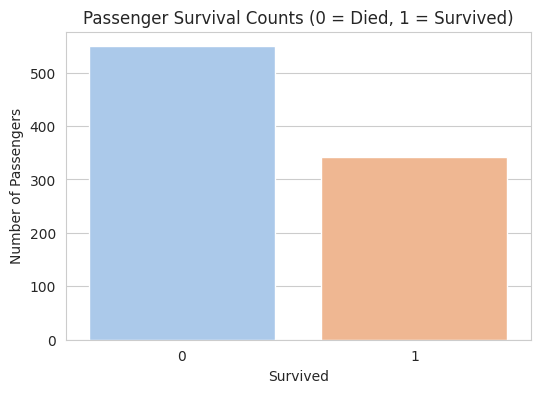

In [24]:
# Visualization 1: Survival counts
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x='Survived', palette='pastel')
plt.title("Passenger Survival Counts (0 = Died, 1 = Survived)")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()


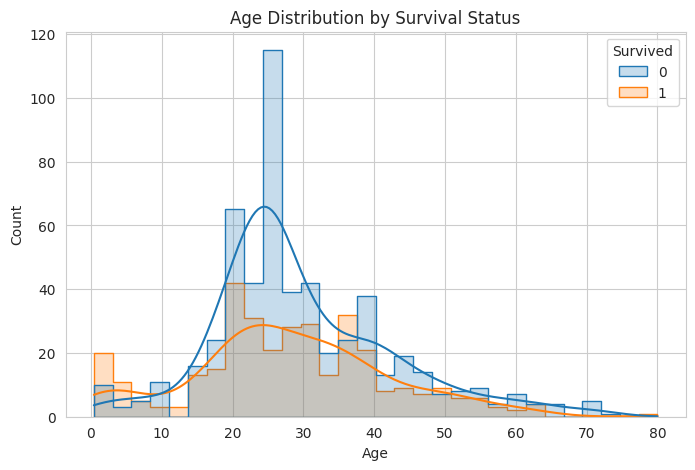

In [25]:
# Visualization 2: Age distribution split by survival
plt.figure(figsize=(8, 5))
sns.histplot(data=train, x='Age', hue='Survived', bins=30, kde=True, element='step')
plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.show()


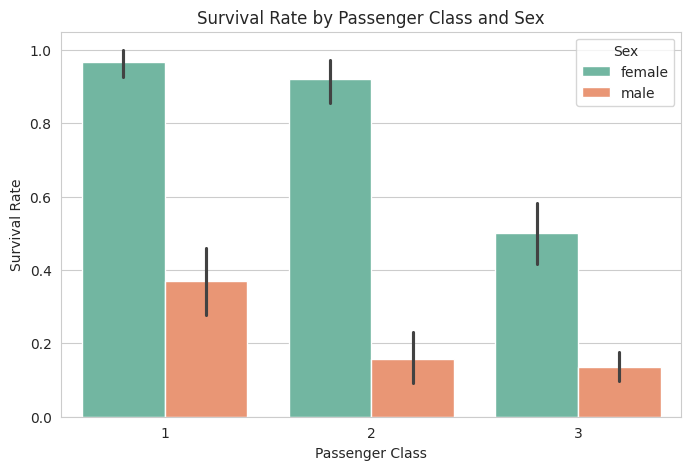

In [26]:
# Visualization 3: Survival rate by passenger class and sex
plt.figure(figsize=(8, 5))
sns.barplot(data=train, x='Pclass', y=train['Survived'].astype(int), hue='Sex', palette='Set2')
plt.title("Survival Rate by Passenger Class and Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()


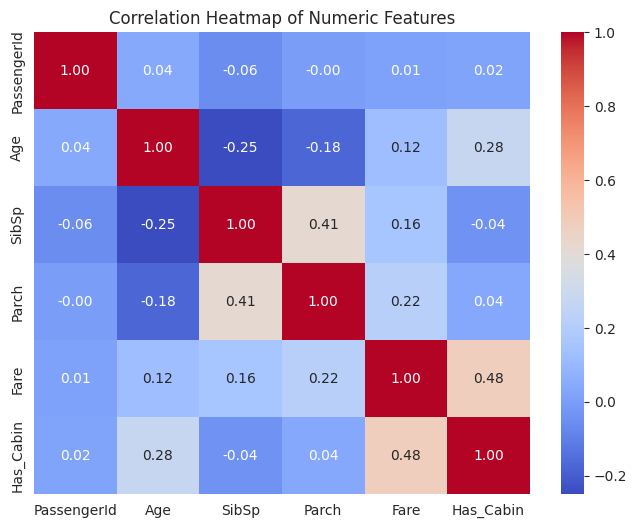

In [27]:
# Bonus Visualization 4: Correlation heatmap of numeric features
numeric_df = train.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [28]:
# 5.2 Groupby summaries
print("Survival rate by Sex:")
print(train.groupby('Sex')['Survived'].apply(lambda x: x.astype(int).mean()))

print("\nSurvival rate by Pclass:")
print(train.groupby('Pclass')['Survived'].apply(lambda x: x.astype(int).mean()))

print("\nSurvival rate by Embarked:")
print(train.groupby('Embarked')['Survived'].apply(lambda x: x.astype(int).mean()))


Survival rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


/tmp/ipykernel_6656/2386720926.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train.groupby('Sex')['Survived'].apply(lambda x: x.astype(int).mean()))
/tmp/ipykernel_6656/2386720926.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train.groupby('Pclass')['Survived'].apply(lambda x: x.astype(int).mean()))
/tmp/ipykernel_6656/2386720926.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(train.grou

## 6. Key Insights

1. **Overall survival rate was ~38%** — the majority of passengers did not survive, consistent with
   historical accounts of the disaster.
2. **Sex was the strongest visible predictor of survival**: women survived at a dramatically higher rate
   than men, reflecting the "women and children first" evacuation protocol.
3. **Passenger class mattered**: 1st class passengers had a notably higher survival rate than 3rd class,
   likely linked to cabin location, proximity to lifeboats, and socio-economic factors.
4. **Age distribution**: young children had relatively higher survival rates, while the bulk of victims
   were adult men in their 20s–40s.
5. **Missingness itself was informative**: passengers with recorded `Cabin` data (mostly higher fare /
   higher class passengers) survived at a higher rate than those without — this is why we preserved that
   signal via the `Has_Cabin` flag instead of just dropping the column.

## 7. Summary of Cleaning Steps Applied
| Column | Issue | Method | Rationale |
|---|---|---|---|
| Duplicates | 0 found (checked) | Dropped if any | Data integrity |
| `Age` | ~20% missing | Median imputation by `Pclass` + `Sex` | Preserves subgroup distribution better than a global median |
| `Embarked` | 2 missing | Mode imputation | Negligible impact given tiny missing count |
| `Cabin` | ~77% missing | Converted to binary `Has_Cabin` flag | Retains signal without unreliable imputation |
| `Fare` (test) | 1 missing | Median by `Pclass` | Fare correlates strongly with class |
| `Survived`, `Pclass`, `Sex`, `Embarked` | Wrong dtype | Cast to `category` | Correct semantic type for discrete groups |
